# Single Particle Tracking simulator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage

## 1. Background generation

### 1.1 Continuous background

1.1.0 Constant background

In [ ]:
def background(x,y):
    return 100 * np.ones_like(x) # 100 to mimic microscope background intensity

1.1.1 Gaussian background

In [ ]:
def background1(x,y):
    sigma = 0.5
    return 100 * np.ones_like(x) +  65535 * (1/(2*np.pi*sigma**2)) * np.exp(-((x-0)**2 + (y-0)**2)/(2*sigma**2))

1.1.2 Off-center Gaussian background

In [ ]:
def background2(x,y):
    sigma = 0.5
    return 100 * np.ones_like(x) +  65535 * (1/(2*np.pi*sigma**2)) * np.exp(-((x-1)**2 + (y-1)**2)/(2*sigma**2))


1.1.3 Off-center diagonal gaussian background 

In [ ]:
def background3(x, y, peak=10000, floor=100, theta_deg=35, offset=0.75, sigma=0.4):
    
    theta = np.deg2rad(theta_deg)

    # Coordinate perpendicular to the band (distance-like in normalized units)
    v = -np.sin(theta) * x + np.cos(theta) * y

    # Bright ridge centered at v = offset
    ridge = np.exp(-0.5 * ((v - offset) / sigma) ** 2)

    # Map ridge (0..1) to intensity (floor..peak)
    return floor + (peak - floor) * ridge


Generation of a high resoltuion grid ('continous' image)

In [3]:
# 1280x1280 high resolution grid (continuous)
x_cont = np.linspace(-3, 3, 1280)
y_cont = np.linspace(-3, 3, 1280)
x_cont_vect, y_cont_vect = np.meshgrid(x_cont, y_cont) 

background_cont = background3(x_cont_vect, y_cont_vect)


In [4]:
def show_img(image):
    plt.imshow(image, cmap='gray', vmin=0, vmax=65535) # 16-bit image range 0->65535

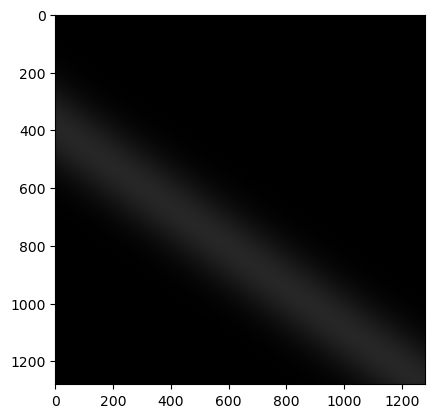

In [5]:
show_img(background_cont)

### 1.2 Discrete background

Sampling with skimage: 10x10 blocks, max sampling

In [7]:
# sampled image: downsample the 1280x1280 image to 128x128 by max-sampling using skimage
from skimage.measure import block_reduce

background_samp = block_reduce(background_cont, block_size=(10, 10), func=np.max)

In [8]:
# function to display continuous and sampled images side by side
def display_cont_samp(cont_img, samp_img):

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # continous image
    axes[0].imshow(cont_img, cmap='gray', vmin=0, vmax=65535) # 16-bit image range 0->65535
    axes[0].set_title("Continuous")

    # sampled image
    axes[1].imshow(samp_img, cmap='gray', interpolation='nearest', vmin=0, vmax=65535)
    axes[1].set_title("Sampled")

    plt.show()

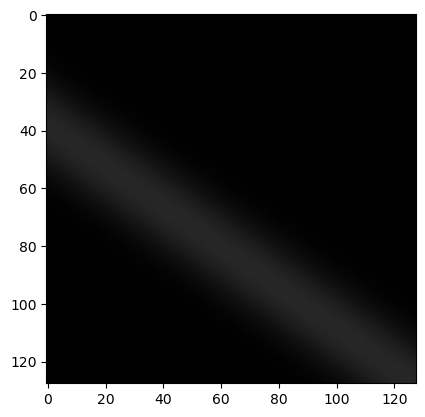

In [9]:
show_img(background_samp)

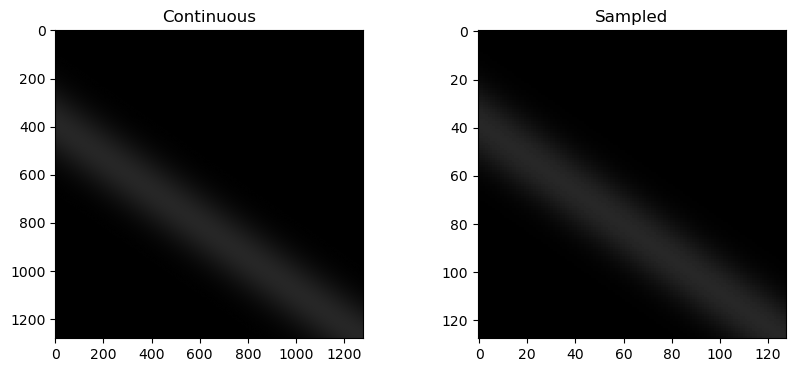

In [55]:
# display discrete and continuous side to side
display_cont_samp(background_cont, background_samp)

## 2. Particles generation

Goal: create a generator of N particles at random positions in (4, 122) (not too close to edges) with diffusion coeff in (0,4)

In [11]:
import random

def generate_particles(N):
    # shape: (tag, x_c, y_c, d)
    particles = np.empty((0, 4))
    for i in range(1, N+1):
        x_c = random.uniform(4, 122)
        y_c = random.uniform(2, 122)
        d = random.randint(0, 4)
        tag = i
        particles = np.append(particles, [(tag, x_c, y_c, d)], axis=0)
    return particles


In [56]:
N = 10
particles = generate_particles(N)

In [57]:
print(particles)  

[[  1.          55.95162716  30.45163564   0.        ]
 [  2.          99.18265245  34.05943487   2.        ]
 [  3.         113.62981932  97.22547465   2.        ]
 [  4.           9.92893857  34.10285281   3.        ]
 [  5.           8.19148853  58.90761252   3.        ]
 [  6.         119.22741687  62.8138566    2.        ]
 [  7.           5.29179163  89.96289527   0.        ]
 [  8.          14.9942075   82.11799504   2.        ]
 [  9.          99.6812481   30.40451161   3.        ]
 [ 10.          39.96359304  29.94208083   4.        ]]


-> particles positions are in (128,128) = size of sampled image

## 4. Particles positioning

### 4.1 Discrete background

Number of particles in sampled image: 10


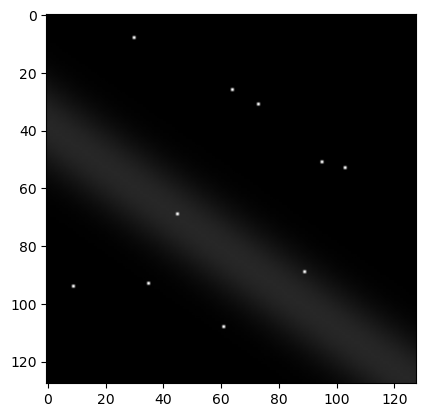

In [13]:
samp_with_particles = background_samp.copy()

# sampled particles positioning: place them at their integer coordinates in the sampled image
for i in range(len(particles)):
    samp_with_particles[int(particles[i,1]), int(particles[i,2])] = 65535 # set to max intensity for visualization

# check number of particles (as pixels with value 65535)
num_particles_sampled = np.sum(samp_with_particles == 65535)

print(f"Number of particles in sampled image: {num_particles_sampled}")

show_img(samp_with_particles)

### 4.1 Continuous background

Also place particles on the continous background:

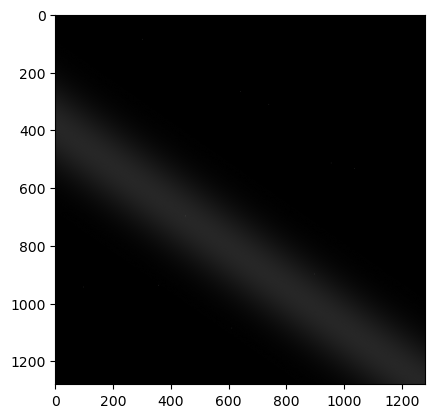

In [14]:
cont_with_particles = background_cont.copy()
for i in range(len(particles)):
    cont_with_particles[int(particles[i,1]*10), int(particles[i,2]*10)] = 65535
    
show_img(cont_with_particles)

In [58]:
print(cont_with_particles.min(), cont_with_particles.max())
print('Number of particles:', np.sum(cont_with_particles == 65535))

100.0 65535.0
Number of particles: 10


10 particles present as single pixels, cannot see them

## 3. Gaussian blurring

In [ ]:
sigma = 2.0

def g(x,y, x_c, y_c, sigma, peak=1):
    return peak * np.exp(-((x-x_c)**2 + (y-y_c)**2)/(2*sigma**2))

In [ ]:
# function to add Gaussian PSF at given position (x_c, y_c)
def add_gaussian_psf(image, x_c, y_c, sigma, amplitude=65535):
    image_g = image.copy()

    x = np.arange(image.shape[1])
    y = np.arange(image.shape[0])
    x_grid, y_grid = np.meshgrid(x, y)

    psf = amplitude * g(x_grid, y_grid, x_c, y_c, sigma).astype(np.float32)
    image_g += psf
    image_g = np.clip(image_g, 0, 65535) # clip to ensure puxel value stays below 65535
    return image_g

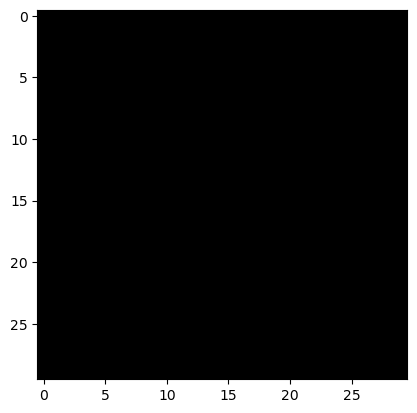

In [18]:
# test gaussian blurring on simple image with one particle
test_img = np.full((30, 30), 100, dtype=np.float32)
show_img(test_img)

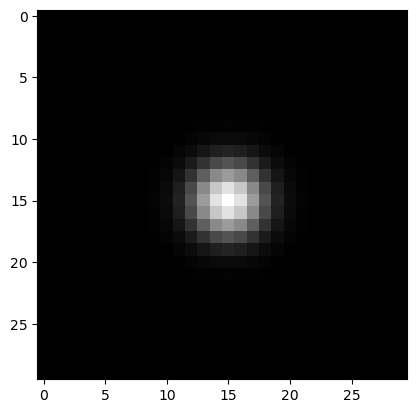

In [19]:
particle = (15, 15)
test_img_g = add_gaussian_psf(test_img, particle[0], particle[1], sigma)
show_img(test_img_g)

test conclusive, can move to higher number of particles

In [20]:
print(test_img_g.min(), test_img_g.max())

100.0 65535.0


gaussian then sample or sample then gaussian?  
-> should be gaussian then sample!

for navigating on the continous image, use 10*[sampled coordinates] => assume these are 'exact' particles centers locations.

In [59]:
print(particles[:,1]*10, particles[:,2]*10)
print('Shape of continous background:', background_cont.shape)

[ 559.51627162  991.82652447 1136.29819316   99.28938575   81.91488534
 1192.27416866   52.91791634  149.942075    996.81248105  399.63593044] [304.51635642 340.59434869 972.25474654 341.02852806 589.07612516
 628.13856604 899.62895271 821.17995038 304.04511612 299.42080827]
Shape of continous background: (1280, 1280)


__Apply Gaussian smoothing on the particles on the continous image:__

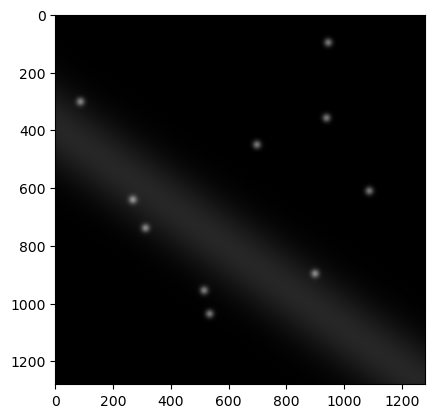

In [22]:
# apply Gaussian blurring to the particles in the continuous image by addintion of subsequent Gaussian PSFs at the particle positions
cont_g = background_cont.copy()

for i in range(len(particles)):
    new_particle_g = add_gaussian_psf(np.zeros_like(cont_g), particles[i,1]*10, particles[i,2]*10, sigma=10.0, amplitude=30000)
    cont_g += new_particle_g
show_img(cont_g)

can now see psf for each particle positioned exactly on continuous image!

__Then extract the 128x128 sampled version:__

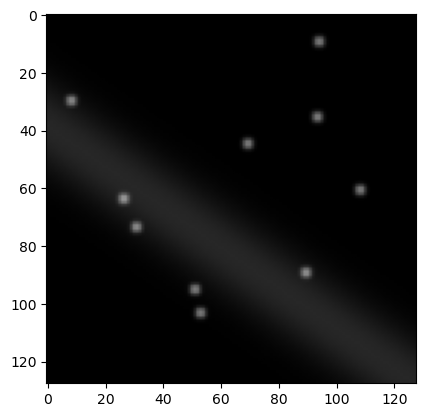

In [23]:
# sample the blurred continuous image to get the final sampled image with particles
samp_g = block_reduce(cont_g, block_size=(10, 10), func=np.max)
show_img(samp_g)

Function summarizing all steps to obtain sampled frame:

In [24]:
# combine particle positioning, gaussian blurring and sampling in one step
def generate_sampled_image_with_particles(background_cont, particles, sigma=10.0, amplitude=30000):
    cont_g = background_cont.copy()
    for i in range(len(particles)):
        new_particle_g = add_gaussian_psf(np.zeros_like(cont_g), particles[i,1]*10, particles[i,2]*10, sigma=sigma, amplitude=amplitude)
        cont_g += new_particle_g
    samp_g = block_reduce(cont_g, block_size=(10, 10), func=np.max)
    return samp_g

## 4. Particles position update

Update following normal diffusion (Brownian motion)

In [ ]:
# update rules

def update(particles):
    particles_updated = np.empty((0, 4))
    for i in range(len(particles)):
        tag, x_c, y_c, d = particles[i]
        theta = random.uniform(0, 2*np.pi) # random direction
        x_c += d*np.cos(theta) # diffusion coeff * random direction (cos)
        y_c += d*np.sin(theta) # diffusion coeff * random direction (sin) (SIGN?)
        particles_updated = np.append(particles_updated, [(tag, x_c, y_c, d)], axis=0)
        
    return particles_updated

Create a master array containing the temporal sequence of all particles positions arrays (30 frames):

In [26]:
F = 30
particles_sequence = [particles]
for frame in range(1, F):
    particles_updated = update(particles_sequence[-1])
    particles_sequence.append(particles_updated)

In [29]:
# Number of frames x number of particles x (tag, x_c, y_c, d)
print(np.array(particles_sequence).shape)

(30, 10, 4)


Extract trajectories

In [27]:
# clean into trajectories (N X F X 2)
trajectories = np.array([particles_sequence[t][:,1:3] for t in range(F)])  # shape (F, nparticles, 2)
print(trajectories.shape)  # should be (F, N, 2)

(30, 10, 2)


Create corresponding sampled frames with Gaussian smoothed particles:

In [28]:
# runtime ~ 30 seconds for 30 frames
frames = []
for particles in particles_sequence:
    samp_img = generate_sampled_image_with_particles(background_cont, particles)
    frames.append(samp_img)

Visualization: stackview

In [ ]:
# make a stack of the frames for visualization
stack = np.stack(frames, axis=0)   # shape (T, H, W)

In [31]:
import stackview
stackview.slice(stack,continuous_update=True)

## 5. Extract Mean Square Displacement

### Try 2: Emilien's function

N: number of particles  
F: number of frames

MSD = 1/N * sum((x_i(t) - x_i(t-tau))^2 + (y_i(t) - y_i(t-tau))^2) for tau in range(1, F - tau) for i in range(N) 

In [32]:
def mean_square_displacement(traj):
    """
    Computes the Mean Square Displacement (MSD) for a particle trajectory, 
    which represents the average squared distance moved over time, useful 
    for analyzing diffusion characteristics.

    Parameters:
    - traj (ndarray): Array of shape (num_steps, 2) representing the x, y positions 
                      of a particle over time.

    Returns:
    - msd (ndarray): Array of MSD values computed for each time lag.
    """
    len = traj.shape[0]
    msd = np.zeros(len)
    for tao in range(1,len):
        # Calculate the square of displacements for each tao time t
        displacements = np.sum((traj[tao:] - traj[:len-tao])**2, axis=1)
        msd[tao] = np.mean(displacements)  # Average displacement for the given lag
    return msd

In [33]:
# Example: first particle
traj = np.array([particles_sequence[t][0,1:3] for t in range(F)])  # shape (F, 2)
msd_traj = mean_square_displacement(traj)

print(msd_traj)

[ 0.          1.          2.1263765   3.33150363  4.55848713  5.46248393
  5.98444298  6.12005891  6.79950877  7.21735422  8.02809033  9.13540672
 10.22013016 11.40523007 12.00368621 12.58924506 12.87148902 12.48545801
 13.38336313 14.40917182 15.44879219 17.03301746 16.81117284 16.2305901
 14.31242694 12.99247272 11.00733589  7.81217077  6.93673237  6.48779603]


In [34]:
def mean_square_displacements(trajectories):
    """
    Computes the Mean Square Displacement (MSD) for multiple particle trajectories.
    The MSD represents the average squared distance moved over time, useful for
    analyzing diffusion characteristics for each particle.

    Parameters:
    - trajectories (ndarray): Array of shape (nparticles, num_steps, 2) representing
                              the x, y positions of each particle over time.

    Returns:
    - msd (ndarray): Array of MSD values with shape (nparticles, num_steps),
                     where each row corresponds to the MSD values of a particle.
    """
    nparticles, num_steps, _ = trajectories.shape
    msd = np.zeros((nparticles, num_steps))

    # Vectorized MSD calculation
    for tao in range(1, num_steps):
        # Compute squared displacements for all particles at this time lag
        displacements = np.sum((trajectories[:, tao:] - trajectories[:, :num_steps-tao])**2, axis=2)
        
        # Store MSD for each particle at this time lag
        msd[:, tao] = np.mean(displacements, axis=1)

    return msd

In [35]:
# now for all particles
trajectories = np.array([particles_sequence[t][:,1:3] for t in range(F)])  # shape (F, nparticles, 2)
msd_values = mean_square_displacements(trajectories.transpose(1, 0, 2))  # shape (nparticles, F, 2)
print(msd_values.shape)

(10, 30)


### Try 1: MSD calculations for single and/or all particles

tau is set as a range of integers to span various number of frames between two states in the trajectory

In [36]:
# tau_range = np.linspace(1,5,5,dtype=int)

In [37]:
# # get MSD values for different tau
# msd_values = []
# for tau in tau_range:
#     print(tau)
#     msd_tau = msd(particles_sequence, int(tau))
#     msd_values.append(msd_tau)
#     print(f'Added {len(msd_tau)} MSD values for tau={tau}')

# print(len(msd_values))

=> msd_values is a list of length 5 containing mst(t) sequences for each tau from 1 to 5

is msd for all particles altogether? or for single particles?

In [38]:
# # plot MSD values for increasing tau
# plt.figure(figsize=(8, 5))
# for i, tau in enumerate(tau_range):
#     plt.plot(msd_values[i], label=f'tau={tau}')
# plt.xlabel('Time (frames)')
# plt.ylabel('MSD')
# plt.title('MSD vs time for different tau')
# plt.legend()


inconclusive

### Try 3: Clean, inspired by Emilien's functions

In [39]:
print(trajectories.shape)
print(trajectories[0])

(30, 10, 2)
[[ 51.54984376  95.54713627]
 [108.69255733  61.13587068]
 [ 53.4554576  103.65464578]
 [  8.76413308  30.25386027]
 [ 26.89052066  64.17606602]
 [ 69.82382532  45.136244  ]
 [ 89.93627067  89.71895472]
 [ 31.27167869  73.97932987]
 [ 94.48517903   9.80128281]
 [ 93.89710937  35.88646502]]


In [40]:
# msd calculation for all particles
def msd(trajectories):
    N, F, _ = trajectories.shape
    msd = np.zeros((N, F))

    # Vectorized MSD calculation
    for tao in range(1, F): # tau spans all possible time lags from 1 to F-1
        # Compute squared displacements for all particles at this time lag
        displacements = np.sum((trajectories[:, tao:] - trajectories[:, :F-tao])**2, axis=2)
        
        # Store MSD for each particle at this time lag
        msd[:, tao] = np.mean(displacements, axis=1)

    return msd

In [41]:
msd_values = msd(trajectories.transpose(1, 0, 2)) # to respect (N, F, 2) shape for msd function
print(msd_values.shape)

(10, 30)


## 6. Estimate diffusion coefficient

4 approaches to deduce estimate the diffusion coeff from MSD curves (Emilien):  
- from pairwise displacement between consecutive positions
- fitting only optiomal nb of MSD values (eg first 10%)
- weighted fitting method
- fitting the full MSD curve (least conclusive)

In [42]:
def estimateDfromMSDs(msds, time_range):
    """
    Estimates the diffusion coefficient (D) for multiple particles from MSD values
    using linear regression without an intercept.
    
    Parameters:
    - msds (numpy array): 2D array of shape (num_particles, msd_len) containing MSD values
                           for multiple particles.
    - time_range (numpy array): 1D array of time values corresponding to MSD.
    
    Returns:
    - D_estimated (numpy array): 1D array of estimated diffusion coefficients for each particle.
    """
    # Solve the least squares problem for multiple MSDs at once
    # Transpose msds to shape (msd_len, num_particles) to fit all particles simultaneously
    slopes = np.linalg.lstsq(time_range.reshape(-1, 1), msds.T, rcond=None)[0][0]
    
    # Diffusion coefficient is the slope divided by 4
    D_estimated = slopes / 4
    return D_estimated  # Shape (num_particles,)

In [43]:
D_estimated = estimateDfromMSDs(msd_values, np.arange(msd_values.shape[1]))
print(D_estimated)

[ 0.14488478  0.31293012 -0.          0.17988309  1.05726672  1.2414992
  1.54157378 -0.         -0.          1.21118887]


### Compare to ground truth diffusion coefficients

In [44]:
# real coefficients
D_GT = particles_sequence[0][:,3]
print(D_GT)

[1. 1. 0. 1. 2. 2. 3. 0. 0. 4.]


In [45]:
# absolute difference
print(np.abs(D_estimated - D_GT))

[0.85511522 0.68706988 0.         0.82011691 0.94273328 0.7585008
 1.45842622 0.         0.         2.78881113]


In [46]:
def computeAndPlotMeanMSD(msds, nparticles, nframes, nposframe, dt):
    # Set up plot for Mean Square Displacement and diffusion coefficient estimation
    plt.figure(figsize=(4, 4))
    time_range = np.arange(nframes * nposframe) * dt / nposframe    # Time points for MSD plot
    #print(time_range)
    D_estimated = estimateDfromMSDs(msds,time_range) # Array to store estimated diffusion coefficients

    # Loop over each particle to calculate and plot its MSD
    for p in range(nparticles):
        plt.plot(time_range, msds[p], lw=0.25, label=f'Particle {p}')
        

    mean_estimated_D =np.mean(D_estimated)
    plt.plot(time_range, mean_estimated_D *4* time_range , 'k--', lw=0.5, label=f'Slope for Particle {p}')

    # Display estimated diffusion coefficients for each particle
    print("Estimated Diffusion Coefficient:", mean_estimated_D)

    # Set plot details
    plt.title("Mean Square Displacement (MSD) and Estimated Diffusion Coefficient")
    plt.xlabel("Time (s)")
    plt.ylabel("MSD (pixels^2)")
    #plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return mean_estimated_D

Estimated Diffusion Coefficient: 0.8961433047107988


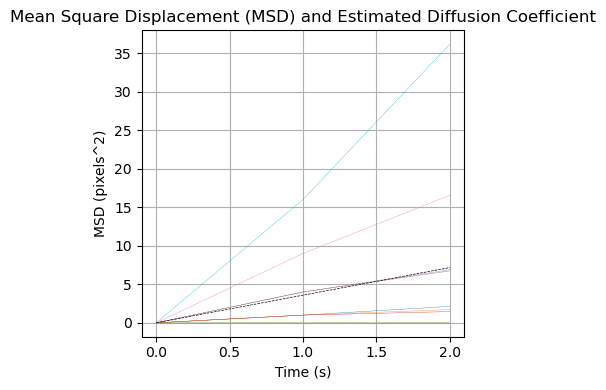

In [47]:
# keep only first 10% of msd values for fitting
msd_values_truncated = msd_values[:, :int(0.1 * F)]  # Keep only first 10% of MSD values for fitting
mean_estimated_D = computeAndPlotMeanMSD(msd_values_truncated, N, int(0.1 * F), 1, 1)

## 7. Work back to particles locations

- gaussian fitting on the sampled image?
- work back to as close as possible to real particles centers?

Now we work on the sampled IMAGES = simulation of microscopy data

In [48]:
# Recall we had created frames:
print(frames[0].shape)
print(len(frames))

(128, 128)
30


In [49]:
# use skimage peak finder to find peaks in the last frame (but could be any frame)
from skimage.feature import peak_local_max

peaks = peak_local_max(frames[-1], min_distance=5, threshold_abs=20000)
print(peaks)
print(len(peaks))

[[ 64  36]
 [ 34   6]
 [ 74  31]
 [ 80  79]
 [ 95  54]
 [103  53]
 [ 48  60]
 [ 59 102]
 [  9  94]
 [ 29  86]]
10


-> have seen 12, 8... -> because of background?

In [50]:
# recall the estimated diffusion coefficients
print(D_estimated)

[ 0.14488478  0.31293012 -0.          0.17988309  1.05726672  1.2414992
  1.54157378 -0.         -0.          1.21118887]


In [ ]:
# fit a Gaussian to the peaks with the estimated diffusion coefficient as sigma (simplification!)
from skimage import data, filters, feature
from scipy.optimize import curve_fit

# define proper 2D Gaussian function for fitting
def gaussian_2d(coords, amp, x0, y0, sigma_x, sigma_y, offset):
    x, y = coords
    g = amp * np.exp(
        -(((x - x0) ** 2) / (2 * sigma_x ** 2) +
          ((y - y0) ** 2) / (2 * sigma_y ** 2))
    ) + offset
    return g.ravel() # .ravel() to flatten the 2D array for curve_fit

In [60]:
# try with first frame
image = frames[0]

Fit failed for peak at (102, 59)
Fit failed for peak at (86, 29)


C:\Users\armel\AppData\Local\Temp\ipykernel_24248\1823151170.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


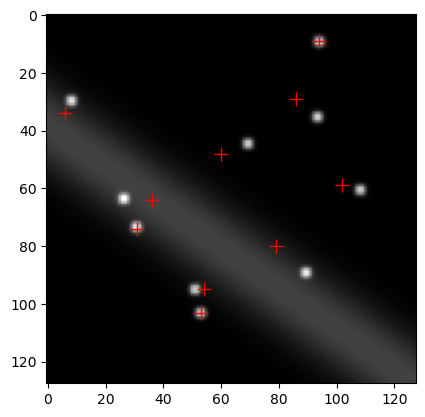

In [62]:
fit_results = []
window_size = 15  # pixels around peak

for (y_peak, x_peak) in peaks:
    # extract a small region around the peak
    y_min, y_max = max(0, y_peak - window_size), min(image.shape[0], y_peak + window_size)
    x_min, x_max = max(0, x_peak - window_size), min(image.shape[1], x_peak + window_size)
    sub_img = image[y_min:y_max, x_min:x_max]

    # create coordinate grid
    y_indices, x_indices = np.indices(sub_img.shape)

    # initial guess for parameters
    initial_guess = (sub_img.max(), sub_img.shape[1] / 2, sub_img.shape[0] / 2, 3, 3, np.median(sub_img))

    try:
        popt, _ = curve_fit(
            gaussian_2d,
            (x_indices, y_indices),
            sub_img.ravel(),
            p0=initial_guess
        )
        fit_results.append(((x_peak, y_peak), popt))
    except RuntimeError:
        print(f"Fit failed for peak at ({x_peak}, {y_peak})")

fig, ax = plt.subplots()
ax.imshow(image, cmap='gray')
ax.plot(peaks[:, 1], peaks[:, 0], 'r+', markersize=10)
plt.show()